<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/BOA003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

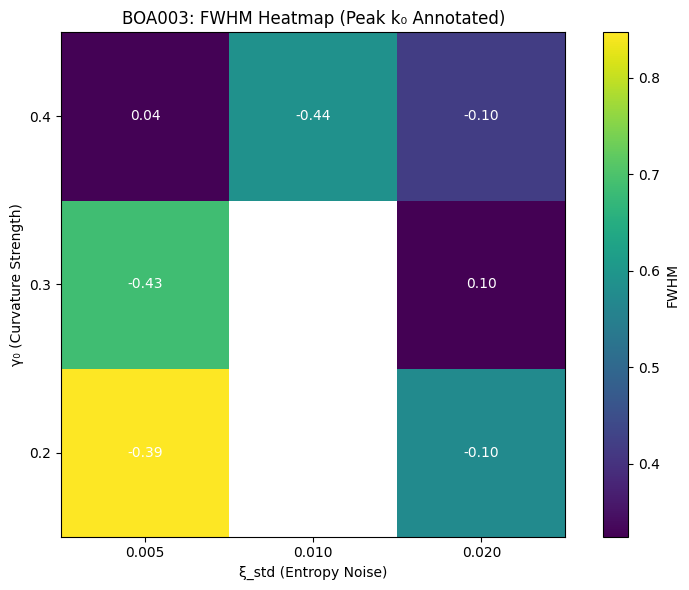

In [1]:
# BOA003: Sweep γ₀ and ξ_std to quantify BAO peak sharpness
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit

# Parameters
N = 256
dt = 0.01
steps = 300
kappa = 0.1
delta = 0.05
epsilon = 0.005

gamma_vals = [0.2, 0.3, 0.4]
xi_vals = [0.005, 0.01, 0.02]

# Gaussian fit function
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Sweep results
fwhm_matrix = np.zeros((len(gamma_vals), len(xi_vals)))
peak_matrix = np.zeros_like(fwhm_matrix)

for i, gamma_0 in enumerate(gamma_vals):
    for j, xi_std in enumerate(xi_vals):
        # Initialize field
        A = np.random.normal(0, 0.1, (N, N))
        for t in range(steps):
            xi = np.random.normal(0, xi_std, (N, N))
            laplacian = (
                np.roll(A, 1, 0) + np.roll(A, -1, 0) +
                np.roll(A, 1, 1) + np.roll(A, -1, 1) - 4 * A
            )
            dA = (-kappa * A + delta * A**2 + epsilon * A**3 + gamma_0 * laplacian + xi) * dt
            A += np.nan_to_num(dA)

        # FFT and radial power spectrum
        fft_A = fftshift(fft2(A))
        power_spectrum = np.abs(fft_A)**2
        y, x = np.indices((N, N))
        center = (N // 2, N // 2)
        r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
        r = r.astype(np.int32)
        tbin = np.bincount(r.ravel(), power_spectrum.ravel())
        nr = np.bincount(r.ravel())
        radial_ps = tbin / (nr + 1e-10)
        k_vals = np.arange(len(radial_ps)) / (N / 2)
        radial_ps_smooth = gaussian_filter(radial_ps, sigma=2)

        # Fit Gaussian to peak region
        fit_mask = (k_vals > 0.15) & (k_vals < 0.35)
        k_fit = k_vals[fit_mask]
        ps_fit = radial_ps_smooth[fit_mask]
        try:
            popt, _ = curve_fit(gaussian, k_fit, ps_fit, p0=[np.max(ps_fit), 0.25, 0.05])
            a_fit, x0_fit, sigma_fit = popt
            fwhm = 2.355 * sigma_fit
            fwhm_matrix[i, j] = fwhm
            peak_matrix[i, j] = x0_fit
        except:
            fwhm_matrix[i, j] = np.nan
            peak_matrix[i, j] = np.nan

# Plot FWHM heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(fwhm_matrix, cmap='viridis', origin='lower')
for i in range(len(gamma_vals)):
    for j in range(len(xi_vals)):
        text = ax.text(j, i, f"{peak_matrix[i, j]:.2f}", ha="center", va="center", color="w")
ax.set_xticks(np.arange(len(xi_vals)))
ax.set_yticks(np.arange(len(gamma_vals)))
ax.set_xticklabels([f"{x:.3f}" for x in xi_vals])
ax.set_yticklabels([f"{g:.1f}" for g in gamma_vals])
ax.set_xlabel("ξ_std (Entropy Noise)")
ax.set_ylabel("γ₀ (Curvature Strength)")
ax.set_title("BOA003: FWHM Heatmap (Peak k₀ Annotated)")
fig.colorbar(im, ax=ax, label="FWHM")
plt.tight_layout()
plt.show()
